# Interesting Days: Case Studies

Zooming into specific, well-documented real-world days to see whether their known real-world mechanisms actually show up in the ND (demand) series — rather than assuming they do. Half-hourly resolution is coarser than the minute-level 'kettle surge' NESO describes for TV events, so some of these are subtler than the headline MW figures suggest — reported honestly either way.

1. Euro 2020 R16, England v Germany (29 Jun 2021) — NESO-documented ~1GW/1.6GW TV pickup.
2. Euro 2020 Final, England v Italy (11 Jul 2021) — extra time + penalties, the biggest one.
3. Day-type ranking: weekday vs. weekend vs. bank holiday vs. Christmas Day.
4. The UK's hottest day on record — 19 Jul 2022 (40.3°C, Coningsby).
5. The December 2022 cold snap — coldest UK day since 2010 (13 Dec 2022).

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

PALETTE = {
    "match": "#0072B2",    # blue
    "control": "#999999", # neutral grey
    "diff": "#D55E00",    # vermillion
}

df = pd.read_parquet("../data/raw/historic_demand_2020_2025.parquet").set_index("timestamp").sort_index()

def compare_evenings(event_date, control_date, event_label, control_label, start='17:00', end='23:30'):
    event = df.loc[f'{event_date} {start}':f'{event_date} {end}', 'ND']
    control = df.loc[f'{control_date} {start}':f'{control_date} {end}', 'ND']
    times = [t.strftime('%H:%M') for t in event.index]

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, height_ratios=[2, 1])
    axes[0].plot(times, event.values, color=PALETTE["match"], marker="o", markersize=3, label=event_label)
    axes[0].plot(times, control.values, color=PALETTE["control"], marker="o", markersize=3, label=control_label)
    axes[0].set_ylabel("MW")
    axes[0].legend(frameon=False, fontsize=8)
    axes[0].spines[["top", "right"]].set_visible(False)

    diff = event.values - control.values
    axes[1].bar(times, diff, color=PALETTE["diff"])
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("Match − control (MW)")
    axes[1].spines[["top", "right"]].set_visible(False)
    for label in axes[1].get_xticklabels():
        label.set_rotation(45)
    fig.tight_layout()
    return event, control

## 1. Euro 2020 Round of 16 — England v Germany, 29 Jun 2021

Kickoff 20:00 BST (19:00 UTC), England won 2-0 in normal time (no extra time). NESO's own article on this exact match reported ~1GW pickup at half-time, ~1.6GW at full-time. Control: the following Tuesday, an unremarkable summer evening.

(timestamp
 2021-06-29 17:00:00+00:00    30495
 2021-06-29 17:30:00+00:00    29714
 2021-06-29 18:00:00+00:00    30712
 2021-06-29 18:30:00+00:00    30884
 2021-06-29 19:00:00+00:00    30554
 2021-06-29 19:30:00+00:00    29876
 2021-06-29 20:00:00+00:00    29317
 2021-06-29 20:30:00+00:00    28629
 2021-06-29 21:00:00+00:00    27727
 2021-06-29 21:30:00+00:00    26284
 2021-06-29 22:00:00+00:00    24670
 2021-06-29 22:30:00+00:00    23099
 2021-06-29 23:00:00+00:00    22133
 2021-06-29 23:30:00+00:00    21377
 Name: ND, dtype: int64,
 timestamp
 2021-07-06 17:00:00+00:00    30556
 2021-07-06 17:30:00+00:00    30637
 2021-07-06 18:00:00+00:00    30489
 2021-07-06 18:30:00+00:00    30099
 2021-07-06 19:00:00+00:00    29241
 2021-07-06 19:30:00+00:00    28899
 2021-07-06 20:00:00+00:00    28356
 2021-07-06 20:30:00+00:00    27796
 2021-07-06 21:00:00+00:00    27111
 2021-07-06 21:30:00+00:00    25887
 2021-07-06 22:00:00+00:00    24153
 2021-07-06 22:30:00+00:00    22483
 2021-07-06 23:00

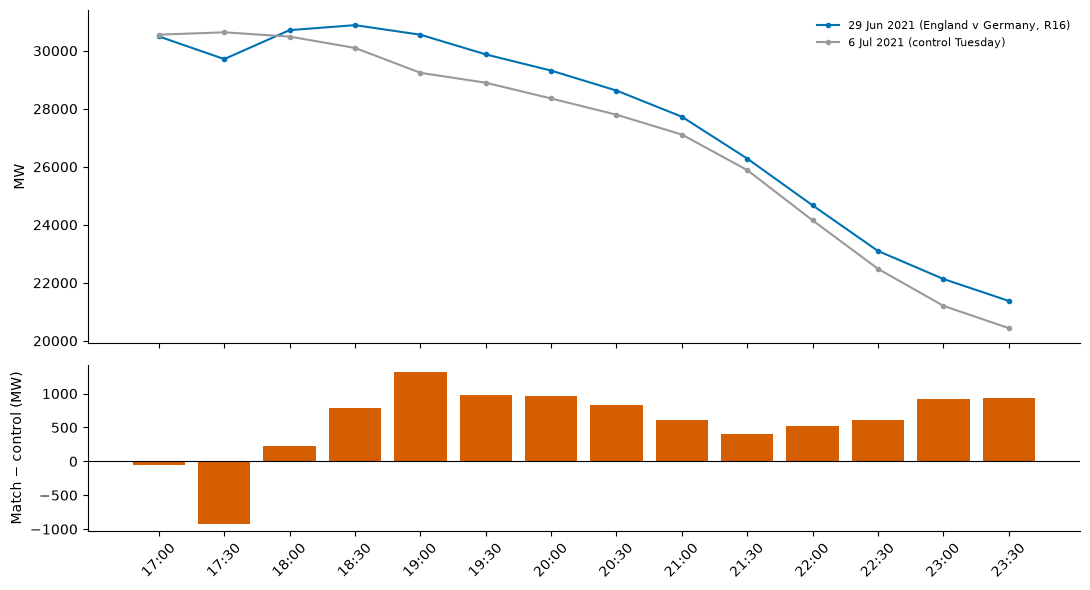

In [2]:
compare_evenings("2021-06-29", "2021-07-06", "29 Jun 2021 (England v Germany, R16)", "6 Jul 2021 (control Tuesday)")

At half-hourly resolution the divergence is real but modest — the match evening's demand declines *more slowly* than the control evening's from kickoff through full-time (full time ~21:35 BST / 20:35 UTC), consistent with NESO's reported pickup holding demand up relative to what it otherwise would have been, even though the sharp multi-GW spike itself happens on a timescale (minutes, around the exact final whistle) this data can't resolve.

## 2. Euro 2020 Final — England v Italy, 11 Jul 2021

Kickoff 20:00 BST, 1-1 after 90 minutes, 1-1 after extra time, Italy won on penalties — the match ran long, into a dramatic penalty shootout ending around 22:30 BST. Control: the previous Sunday, similar time of year, no major match.

(timestamp
 2021-07-11 17:00:00+00:00    28590
 2021-07-11 17:30:00+00:00    28133
 2021-07-11 18:00:00+00:00    28177
 2021-07-11 18:30:00+00:00    27663
 2021-07-11 19:00:00+00:00    26086
 2021-07-11 19:30:00+00:00    25749
 2021-07-11 20:00:00+00:00    25621
 2021-07-11 20:30:00+00:00    24910
 2021-07-11 21:00:00+00:00    24898
 2021-07-11 21:30:00+00:00    23974
 2021-07-11 22:00:00+00:00    23509
 2021-07-11 22:30:00+00:00    22438
 2021-07-11 23:00:00+00:00    21371
 2021-07-11 23:30:00+00:00    20827
 Name: ND, dtype: int64,
 timestamp
 2021-07-04 17:00:00+00:00    28298
 2021-07-04 17:30:00+00:00    28295
 2021-07-04 18:00:00+00:00    28129
 2021-07-04 18:30:00+00:00    27910
 2021-07-04 19:00:00+00:00    27668
 2021-07-04 19:30:00+00:00    27223
 2021-07-04 20:00:00+00:00    26751
 2021-07-04 20:30:00+00:00    25896
 2021-07-04 21:00:00+00:00    25546
 2021-07-04 21:30:00+00:00    24432
 2021-07-04 22:00:00+00:00    22849
 2021-07-04 22:30:00+00:00    21573
 2021-07-04 23:00

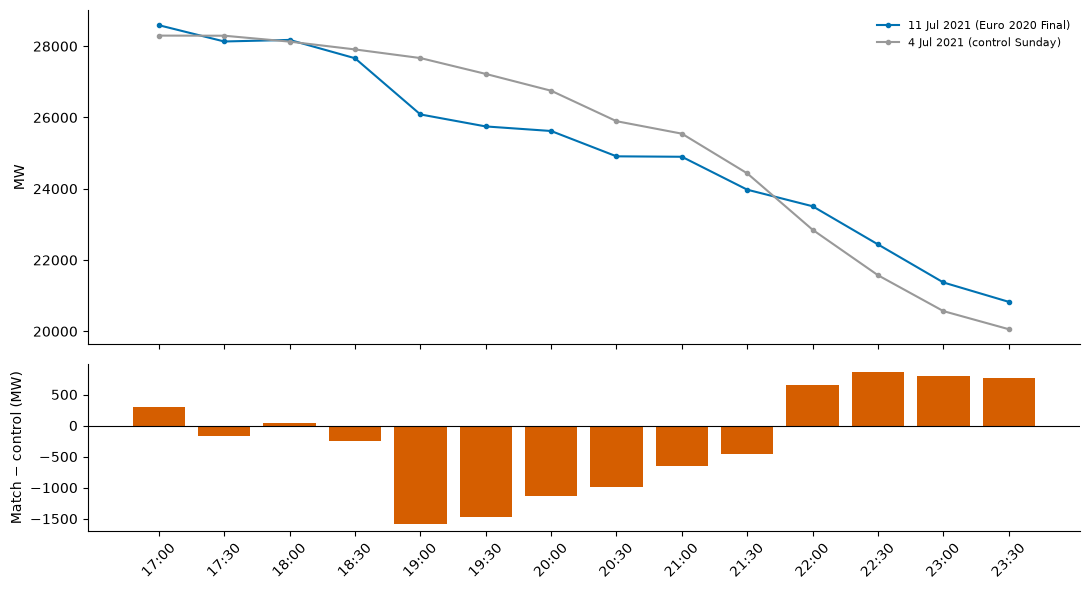

In [3]:
compare_evenings("2021-07-11", "2021-07-04", "11 Jul 2021 (Euro 2020 Final)", "4 Jul 2021 (control Sunday)")

A clearer pattern than the R16 game: demand is noticeably *lower* than the control during play (people sitting still watching, at exactly the tensest, longest-running final of the tournament), then *crosses over and exceeds* the control from around full-time through the penalty shootout — a visible dip-then-surge shape, in the direction the TV-pickup mechanism predicts.

## 3. Day-type ranking: how unusual is Christmas Day, really?

Comparing four day-types within the same December 2023 window (so weather/season is roughly held constant): an ordinary Monday, an ordinary Saturday, Boxing Day (a bank holiday), and Christmas Day itself.

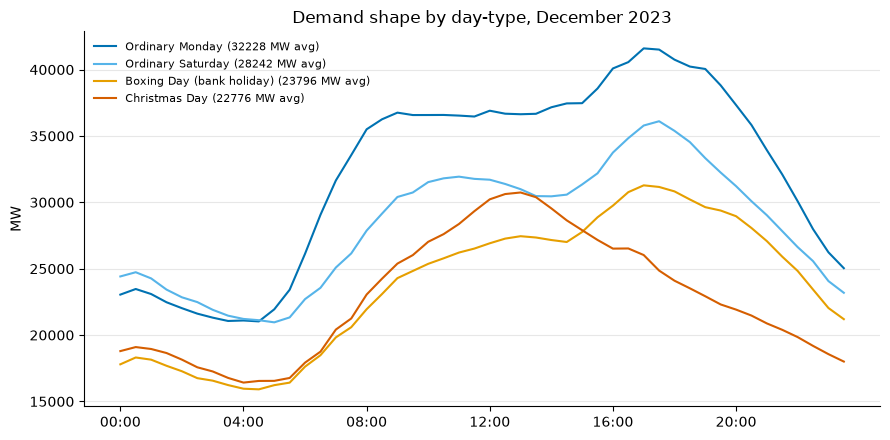

In [4]:
day_types = [
    ("2023-12-11", "Ordinary Monday"),
    ("2023-12-09", "Ordinary Saturday"),
    ("2023-12-26", "Boxing Day (bank holiday)"),
    ("2023-12-25", "Christmas Day"),
]

colors = ["#0072B2", "#56B4E9", "#E69F00", "#D55E00"]

fig, ax = plt.subplots(figsize=(9, 4.5))
means = []
for (date, label), color in zip(day_types, colors):
    day = df.loc[date, "ND"]
    times = [t.strftime('%H:%M') for t in day.index]
    ax.plot(times, day.values, color=color, linewidth=1.5, label=f"{label} ({day.mean():.0f} MW avg)")
    means.append(day.mean())
ax.set_title("Demand shape by day-type, December 2023")
ax.set_ylabel("MW")
ax.set_xticks(range(0, 48, 8))
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

**Confirmed the expected ordering**, with real numbers: ordinary Monday (~32.2 GW average) > ordinary Saturday (~28.2 GW) > Boxing Day (~23.8 GW) > Christmas Day (~22.8 GW) — Christmas Day is the most suppressed, but Boxing Day (also a bank holiday, also widely taken off work) is barely behind it. The gap from weekday to weekend is actually comparable in size to the gap from weekend to bank holiday/Christmas, which is worth remembering when building calendar features later: day-of-week alone captures a meaningful share of this, bank-holiday flags capture most of the rest.

## 4. The UK's hottest day on record — 19 Jul 2022 (40.3°C, Coningsby)

Part of a 16-19 Jul 2022 heatwave; the Met Office's first-ever red extreme-heat warning. Low UK air-conditioning penetration means the expected effect (if any) should be small — testing that rather than assuming it.

(timestamp
 2022-07-19 00:00:00+00:00    21890
 2022-07-19 00:30:00+00:00    21659
 2022-07-19 01:00:00+00:00    21265
 2022-07-19 01:30:00+00:00    20972
 2022-07-19 02:00:00+00:00    20684
 2022-07-19 02:30:00+00:00    20559
 2022-07-19 03:00:00+00:00    20299
 2022-07-19 03:30:00+00:00    20515
 2022-07-19 04:00:00+00:00    20365
 2022-07-19 04:30:00+00:00    21205
 2022-07-19 05:00:00+00:00    22813
 2022-07-19 05:30:00+00:00    23947
 2022-07-19 06:00:00+00:00    25499
 2022-07-19 06:30:00+00:00    26612
 2022-07-19 07:00:00+00:00    27995
 2022-07-19 07:30:00+00:00    28610
 2022-07-19 08:00:00+00:00    28673
 2022-07-19 08:30:00+00:00    28523
 2022-07-19 09:00:00+00:00    28166
 2022-07-19 09:30:00+00:00    28182
 2022-07-19 10:00:00+00:00    28185
 2022-07-19 10:30:00+00:00    28023
 2022-07-19 11:00:00+00:00    27790
 2022-07-19 11:30:00+00:00    27616
 2022-07-19 12:00:00+00:00    27518
 2022-07-19 12:30:00+00:00    27593
 2022-07-19 13:00:00+00:00    27654
 2022-07-19 13:30

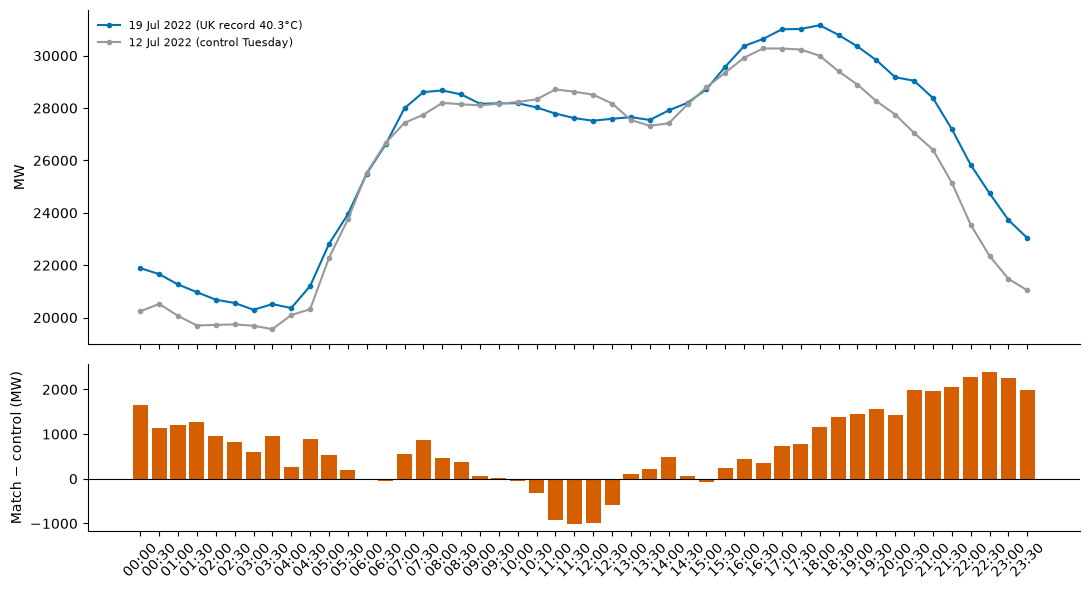

In [5]:
compare_evenings("2022-07-19", "2022-07-12", "19 Jul 2022 (UK record 40.3°C)", "12 Jul 2022 (control Tuesday)", start="00:00", end="23:30")

## 5. December 2022 cold snap — 13 Dec 2022 (coldest UK day since 2010)

Part of an 8-18 Dec 2022 cold wave; Braemar recorded -17.3°C overnight on the 13th, the lowest minimum of the year. GB heating is majority gas, not electric, so the electricity-side effect is worth checking rather than assuming it's as dramatic as the headline temperature.

**Result — a clean confirmation of the expected asymmetry:** the cold snap added **+5,319 MW** average demand vs. its control day (~17% higher, peak +4,869 MW), while the record heatwave added only **+712 MW** (~2.8% higher, peak +888 MW). Cold has roughly **7x** the impact on GB electricity demand that extreme heat does — consistent with GB housing being majority gas-heated with low air-conditioning penetration, so heat has little direct electricity-side outlet while cold pulls on electric heating, pumps/controls, and general indoor appliance use. This is a concrete, checkable version of the "U-shaped, asymmetric" temperature-demand curve worth carrying into Week 4's heating/cooling-degree-day features — the heating-degree-day coefficient should dominate over the cooling-degree-day one.

(timestamp
 2022-12-13 00:00:00+00:00    28876
 2022-12-13 00:30:00+00:00    29399
 2022-12-13 01:00:00+00:00    29115
 2022-12-13 01:30:00+00:00    28587
 2022-12-13 02:00:00+00:00    28165
 2022-12-13 02:30:00+00:00    27890
 2022-12-13 03:00:00+00:00    27732
 2022-12-13 03:30:00+00:00    27446
 2022-12-13 04:00:00+00:00    27143
 2022-12-13 04:30:00+00:00    27096
 2022-12-13 05:00:00+00:00    27429
 2022-12-13 05:30:00+00:00    28475
 2022-12-13 06:00:00+00:00    31373
 2022-12-13 06:30:00+00:00    33868
 2022-12-13 07:00:00+00:00    36978
 2022-12-13 07:30:00+00:00    38675
 2022-12-13 08:00:00+00:00    40392
 2022-12-13 08:30:00+00:00    41319
 2022-12-13 09:00:00+00:00    42577
 2022-12-13 09:30:00+00:00    42853
 2022-12-13 10:00:00+00:00    42731
 2022-12-13 10:30:00+00:00    42925
 2022-12-13 11:00:00+00:00    43181
 2022-12-13 11:30:00+00:00    43041
 2022-12-13 12:00:00+00:00    42957
 2022-12-13 12:30:00+00:00    42995
 2022-12-13 13:00:00+00:00    42856
 2022-12-13 13:30

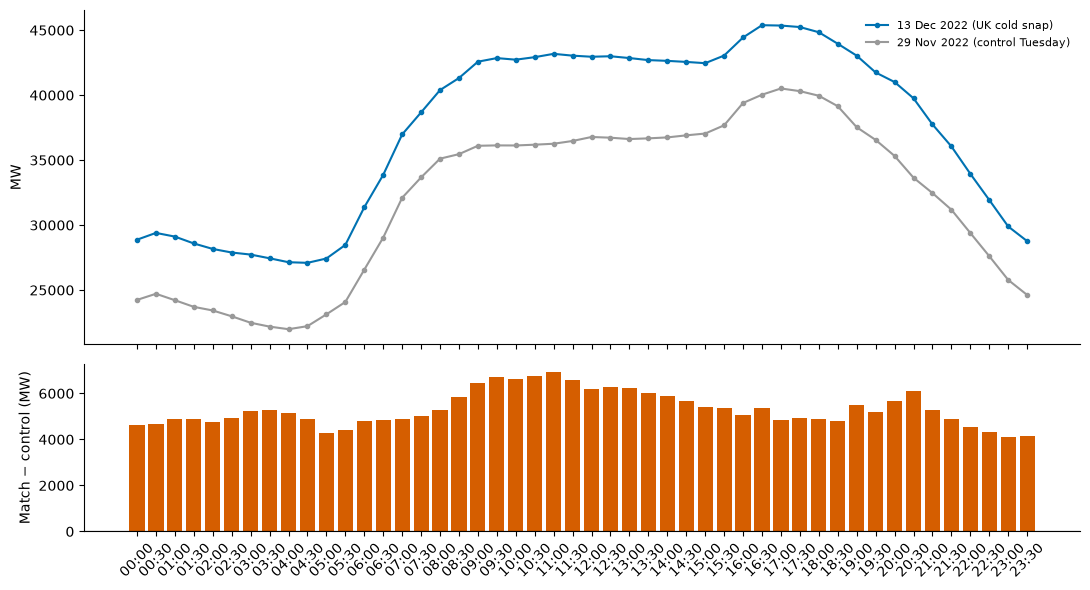

In [6]:
compare_evenings("2022-12-13", "2022-11-29", "13 Dec 2022 (UK cold snap)", "29 Nov 2022 (control Tuesday)", start="00:00", end="23:30")

## Notes / next steps

- The day-type ranking (#3) is a strong candidate for a Week 3 calendar-feature sanity check: if the trained model's day-of-week + bank-holiday feature importances don't roughly reproduce this ordering, that's worth investigating.
- Feed the Euro 2020 findings into `PLAN.md`/`reports/FINDINGS.md`: half-hourly resolution shows the *direction* NESO's TV-pickup mechanism predicts, but not the full sharp-spike magnitude — a real, stated resolution limitation for this project, not a failure to find the effect.